### Import Libraries

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Literal, Optional
from pydantic import BaseModel, Field
import re
import json
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

True

In [4]:
MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

In [5]:
from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(
    model="ministral-14b-2512",
    api_key=MISTRAL_API_KEY,
    temperature=0
)

In [6]:
### test api and llm_call

response = llm.invoke("What is a LangGraph workflow?")
print(response.content)

A **LangGraph workflow** is a structured, modular approach to building **multi-agent, multi-step, and multi-tool workflows** using **LangGraph**, a framework designed for orchestrating complex AI-driven processes. It extends the capabilities of **LangChain** by enabling **parallel execution, dynamic routing, and stateful interactions** between multiple agents, tools, and steps.

---

### **Key Concepts of LangGraph Workflows**
1. **Graph-Based Structure**
   - Workflows are represented as **directed graphs** where nodes (steps) are connected by edges (transitions).
   - Each node can be a **tool, agent, or function**, and edges define how data flows between them.

2. **Dynamic Routing**
   - Unlike linear workflows (e.g., LangChain’s `SequentialChain`), LangGraph allows **conditional branching** based on intermediate outputs.
   - Example: A workflow might split into two paths—one for "yes" responses and another for "no."

3. **State Management**
   - Workflows maintain a **shared stat

In [7]:
## job state
class JobState(TypedDict):
    
    resume: str
    job_description: str
    resume_analysis: dict
    job_analysis: dict
    technical_analysis: dict
    experience_analysis: dict
    matching_skills: List[str]
    missing_skills: List[str]
    technical_gaps: List[str]
    experience_gaps: List[str]
    match_score: int
    match_category: str
    match_reasoning: str
    skill_gap_analysis: dict
    application_message: str
    criticism: str
    quality_score: int
    iteration: int
    human_feedback: str
    final_application: str

START
  │
  ▼
process_input
  │
  ├───────────────┐
  ▼               ▼
analyse_resume   analyse_job
  │               │
  └───────┬───────┘
          ▼
   ┌───────────────┐
   │    PARALLEL   │
   └───────────────┘
       │       │
       ▼       ▼
 technical   experience
 analysis    analysis
       │       │
       └───┬───┘
           ▼
    combine_analysis
           │
           ▼
     calculate_match
           │
           ▼
     classify_match
        /       \
       /         \
 LOW_MATCH     HIGH/MEDIUM
    │              │
    ▼              │
skill_gap          │
    │              │
    └──────┬───────┘
           ▼
 generate_application
           │
           ▼
 critique_application
           │
           ▼
      quality_check
       /          \
      /            \
   Good            Poor
    │               │
    ▼               ▼
human_review    Generate Again
    │                ↑
 ┌──┴──┐             │
 ▼     ▼             │
Approve Improve ─────┘
  │
  ▼
finalize_application
  │
  ▼
 END

In [8]:
def clean_text(text) -> str:
    text = str(text).strip()
    text = re.sub(r"[ \t]+", " ", text)       
    text = re.sub(r"\n{3,}", "\n\n", text)   
    return text

In [9]:
## process_input

def process_input(state: JobState):
    resume = str(state.get("resume", "")).strip()
    jd = str(state.get("job_description", "")).strip()

    # Remove extra whitespace
    resume = " ".join(resume.split())
    jd = " ".join(jd.split())

    # Check after cleaning
    if not resume or not jd:
        raise ValueError("Resume and Job Description are required.")

    return {
        "resume": clean_text(resume),
        "job_description": clean_text(jd)
    }

In [10]:
## resume analysis
class ResumeAnalysis(BaseModel):
    skills: List[str] = Field(description="Technical and domain skills")
    tools: List[str] = Field(description="Libraries, frameworks, platforms, and tools")
    experience: List[str] = Field(description="Relevant work or internship experience")
    projects: List[str] = Field(description="Projects mentioned in the resume")
    education: List[str] = Field(description="Educational qualifications")

In [11]:
## analyse resume

def analyse_resume(state: JobState) -> dict:
    resume_llm = llm.with_structured_output(ResumeAnalysis)
    prompt = (
        "Extract structured information from this resume. "
        "Only include what is explicitly stated; do not infer or invent.\n\n"
        f"RESUME:\n{state['resume']}"
    )
    result = resume_llm.invoke(prompt)
    return {"resume_analysis": result.model_dump()}


In [12]:
### jd_analysis
class JobDescriptionAnalysis(BaseModel):
    required_skills: List[str]
    preferred_skills: List[str]
    experience_requirements: List[str]
    responsibilities: List[str]
    technologies: List[str]
    education_requirements: List[str]

In [13]:
## analyse_jd
def analyse_job_description(state: JobState):
    jd_llm = llm.with_structured_output(JobDescriptionAnalysis)
    prompt = (
        "analyse the following job description and extract only information "
        "explicitly stated in it.\n\n"
        "Extract:\n"
        "- Required technical skills\n"
        "- Preferred technical skills\n"
        "- Required experience\n"
        "- Job responsibilities\n"
        "- Required education\n"
        "- Preferred qualifications\n\n"
        "Do not infer or invent requirements.\n\n"
        f"JOB DESCRIPTION:\n{state['job_description']}"

    )
    result = jd_llm.invoke(prompt)
    return {"job_analysis": result.model_dump()}

In [14]:
class TechnicalAnalysis(BaseModel):
    matching_skills: List[str] = Field(description="Job-required skills/tools the candidate has")
    missing_skills: List[str] = Field(description="Job-required skills/tools the candidate lacks")
    technical_score: int = Field(ge=0, le=100, description="Technical fit, 0-100")

In [15]:
### technical_analysis
def technical_analysis(state: JobState):
    technical_llm = llm.with_structured_output(TechnicalAnalysis)
    prompt = (
        "Compare the candidate's technical skills and tools against the job requirements.\n"
        "Match semantically (e.g. 'Postgres' counts toward 'SQL'), but never credit a skill "
        "that isn't evidenced in the resume. Weigh required skills more than preferred ones.\n\n"
        f"RESUME ANALYSIS:\n{json.dumps(state['resume_analysis'], indent=2)}\n\n"
        f"JOB ANALYSIS:\n{json.dumps(state['job_analysis'], indent=2)}"
    )
    result = technical_llm.invoke(prompt)
    return {"technical_analysis": result.model_dump()}

In [16]:
class ExperienceAnalysis(BaseModel):
    experience_match: bool = Field(description="Does the candidate meet the experience requirement overall?")
    experience_score: int = Field(ge=0, le=100, description="Experience fit, 0-100")
    experience_gaps: List[str] = Field(description="Specific experience the job wants but the resume lacks")

In [17]:
## experience analysis
def analyse_experience(state: JobState):
    experience_llm = llm.with_structured_output(ExperienceAnalysis)
    prompt = (
        "Compare the candidate's experience against the job's experience requirements. "
        "Consider relevant work experience, internships, projects, required years, and "
        "relevant responsibilities. Only use what is stated.\n\n"
        f"RESUME ANALYSIS:\n{json.dumps(state['resume_analysis'], indent=2)}\n\n"
        f"JOB ANALYSIS:\n{json.dumps(state['job_analysis'], indent=2)}"
    )
    result = experience_llm.invoke(prompt)
    return {"experience_analysis": result.model_dump()}

In [18]:
##combine_analysis

def combine_analysis(state: JobState) -> dict:
    tech = state["technical_analysis"]
    exp = state["experience_analysis"]
    return {
        "matching_skills": tech["matching_skills"],
        "missing_skills": tech["missing_skills"],
        "technical_gaps": tech["missing_skills"],
        "experience_gaps": exp["experience_gaps"],
    }

In [19]:
class MatchClassification(BaseModel):
    reasoning: str = Field(description="One or two sentences justifying the category")
    match_category: Literal["HIGH_MATCH", "MEDIUM_MATCH", "LOW_MATCH"]

In [20]:
class SkillGapAnalysis(BaseModel):
    critical_missing_skills: List[str] = Field(description="Missing skills that are essential for the role")
    partial_matches: List[str] = Field(description="Skills the candidate partly has, with what is missing")
    areas_to_improve: List[str] = Field(description="What the candidate should learn or strengthen")
    transferable_skills: List[str] = Field(description="Existing skills that carry over to this role")

In [21]:
## calculate_match

def calculate_match(state: JobState):
    tech_score = state["technical_analysis"]["technical_score"]
    exp_score = state["experience_analysis"]["experience_score"]
    match_score = round(tech_score * 0.70 + exp_score * 0.30)
    return {"match_score": match_score}

In [22]:
## classify match

def classify_match(state: JobState):
    classify_llm = llm.with_structured_output(MatchClassification)
    prompt = (
        "Classify how well this candidate fits the job.\n"
        "Guideline: score >= 75 is usually HIGH_MATCH, 50-74 MEDIUM_MATCH, below 50 LOW_MATCH. "
        "You may go one level lower if a critical required skill is missing, "
        "but explain why in your reasoning.\n\n"
        f"MATCH SCORE: {state['match_score']}\n"
        f"MISSING SKILLS: {state['missing_skills']}\n"
        f"EXPERIENCE GAPS: {state['experience_gaps']}\n\n"
        f"RESUME ANALYSIS:\n{json.dumps(state['resume_analysis'], indent=2)}\n\n"
        f"JOB ANALYSIS:\n{json.dumps(state['job_analysis'], indent=2)}"
    )
    result = classify_llm.invoke(prompt)
    return {
        "match_category": result.match_category,
        "match_reasoning": result.reasoning,
    }

In [23]:
## analyse skill gaps

def analyse_skill_gaps(state: JobState):
    skill_gap_llm = llm.with_structured_output(SkillGapAnalysis)
    prompt = (
        "analyse the skill gaps between this candidate and the job. "
        "Only use information that is stated; do not invent skills.\n\n"
        f"MISSING SKILLS: {state['missing_skills']}\n\n"
        f"RESUME ANALYSIS:\n{json.dumps(state['resume_analysis'], indent=2)}\n\n"
        f"JOB ANALYSIS:\n{json.dumps(state['job_analysis'], indent=2)}"
    )
    result = skill_gap_llm.invoke(prompt)
    return {"skill_gap_analysis": result.model_dump()}


In [24]:
## generate application

def generate_application(state: JobState):
    return {"application_message": f"[placeholder] category={state['match_category']}"}

In [25]:
## route after classification
def route_after_classification(state: JobState) -> str:
    if state.get("match_category") == "LOW_MATCH":
        return "analyse_skill_gaps"
    return "generate_application"

In [26]:
class Critique(BaseModel):
    criticism: str = Field(description="Specific, actionable feedback on what to fix")
    quality_score: int = Field(ge=1, le=10, description="Overall quality, 1-10")

In [27]:
writer_llm = ChatMistralAI(model="ministral-14b-2512", temperature=0.7)

In [28]:
MAX_ITERATIONS = 3
QUALITY_THRESHOLD = 8

def generate_application(state: JobState):
    iteration = state.get("iteration", 0) + 1

    prompt = (
        "Write a concise, personalized job application message for this candidate.\n"
        "Rules:\n"
        "- Do NOT invent experience, employers, or numbers.\n"
        "- Do NOT claim skills that are not in the resume analysis.\n"
        "- Highlight the most relevant experience for this job.\n"
        "- Align the message with the job description.\n"
        "- Keep it under 200 words and professional in tone.\n"
        "- Use [Your Name] as a placeholder for the signature.\n\n"
        f"MATCH SCORE: {state['match_score']} ({state['match_category']})\n"
        f"MATCHING SKILLS: {state['matching_skills']}\n"
        f"MISSING SKILLS: {state['missing_skills']}\n"
        f"SKILL GAP ANALYSIS: {json.dumps(state.get('skill_gap_analysis', 'not applicable'))}\n\n"
        f"RESUME ANALYSIS:\n{json.dumps(state['resume_analysis'], indent=2)}\n\n"
        f"JOB ANALYSIS:\n{json.dumps(state['job_analysis'], indent=2)}"
    )
    if state.get("application_message"):
        prompt += f"\n\nPREVIOUS DRAFT:\n{state['application_message']}"
    if state.get("criticism"):
        prompt += f"\n\nCRITIC FEEDBACK TO ADDRESS:\n{state['criticism']}"
    if state.get("human_feedback") and state["human_feedback"] != "IMPROVE":
        prompt += f"\n\nUSER FEEDBACK TO ADDRESS:\n{state['human_feedback']}"
    if state.get("application_message"):
        prompt += "\n\nRewrite the draft, fixing the issues above."

    result = writer_llm.invoke(prompt)
    return {"application_message": result.content, "iteration": iteration}

In [29]:
def critique_application(state: JobState):
    structured_llm = llm.with_structured_output(Critique)
    prompt = (
        "You are a strict hiring-communications reviewer. Evaluate the application message on:\n"
        "relevance, accuracy, professionalism, clarity, job alignment, hallucination "
        "(any claim not supported by the resume analysis), grammar, conciseness.\n"
        "Any hallucinated skill or experience must cap the score at 5.\n"
        "Give specific, actionable feedback.\n\n"
        f"APPLICATION MESSAGE:\n{state['application_message']}\n\n"
        f"JOB DESCRIPTION:\n{state['job_description']}\n\n"
        f"RESUME ANALYSIS:\n{json.dumps(state['resume_analysis'], indent=2)}"
    )
    result = structured_llm.invoke(prompt)
    return {"criticism": result.criticism, "quality_score": result.quality_score}

In [30]:
### quality check
def quality_check(state: JobState):
    if state["quality_score"] >= QUALITY_THRESHOLD:
        return "good"
    if state["iteration"] >= MAX_ITERATIONS:
        return "good"          # out of retries: move on with the best we have
    return "retry"

In [31]:
## human_review

def human_review(state: JobState):
    print("\n" + "=" * 60)
    print("FINAL APPLICATION")
    print("=" * 60)
    print(state["application_message"])

    print("\n" + "=" * 60)
    print("CRITIC FEEDBACK")
    print("=" * 60)
    print(state["criticism"])

    print(f"\nQuality Score: {state['quality_score']}/10")

    feedback = input(
        "\nEnter 'APPROVE' to accept or provide feedback to improve: "
    ).strip()

    return {
        "human_feedback": feedback
    }

In [32]:
## route after human review
def route_after_human_review(state: JobState):
    feedback = state.get("human_feedback", "").strip()
    if feedback.upper() == "APPROVE":
        return "finalize"
    return "improve"

In [33]:
def finalize_application(state: JobState):
    return {
        "final_application": state["application_message"]
    }

In [34]:
graph = StateGraph(JobState)

In [ ]:
## add nodes
graph.add_node("process_input", process_input)
graph.add_node("analyse_resume", analyse_resume)
graph.add_node("analyse_job_description", analyse_job_description)
graph.add_node("technical_analysis", technical_analysis)
graph.add_node("experience_analysis", analyse_experience)
graph.add_node("combine_analysis", combine_analysis)
graph.add_node("calculate_match", calculate_match)
graph.add_node("classify_match", classify_match)
graph.add_node("analyse_skill_gaps", analyse_skill_gaps)
graph.add_node("generate_application", generate_application)
graph.add_node("critique_application", critique_application)
graph.add_node("human_review", human_review)
graph.add_node("finalize", finalize_application)

In [ ]:
## edges
# 1. Start to process input
graph.add_edge(START, "process_input")

# 2. Parallel branch: process_input -> analyse_resume & analyse_job_description
graph.add_edge("process_input", "analyse_resume")
graph.add_edge("process_input", "analyse_job_description")

# 3. Both analyses feed into technical_analysis & experience_analysis
graph.add_edge("analyse_resume", "technical_analysis")
graph.add_edge("analyse_job_description", "technical_analysis")
graph.add_edge("analyse_resume", "experience_analysis")
graph.add_edge("analyse_job_description", "experience_analysis")

# 4. Combine parallel analyses
graph.add_edge("technical_analysis", "combine_analysis")
graph.add_edge("experience_analysis", "combine_analysis")

# 5. Match calculation & classification
graph.add_edge("combine_analysis", "calculate_match")
graph.add_edge("calculate_match", "classify_match")

# 6. Conditional edge after match classification:
#    LOW_MATCH -> analyse_skill_gaps | HIGH/MEDIUM -> generate_application
graph.add_conditional_edges(
    "classify_match",
    route_after_classification,
    {
        "analyse_skill_gaps": "analyse_skill_gaps",
        "generate_application": "generate_application",
    },
)

# 7. Skill gap analysis leads to application generation
graph.add_edge("analyse_skill_gaps", "generate_application")

# 8. Application generation flows to critic
graph.add_edge("generate_application", "critique_application")

# 9. Quality check conditional loop:
#    good -> human_review | retry -> generate_application
graph.add_conditional_edges(
    "critique_application",
    quality_check,
    {
        "good": "human_review",
        "retry": "generate_application",
    },
)

# 10. Human review conditional loop:
#     APPROVE -> finalize | IMPROVE -> generate_application
graph.add_conditional_edges(
    "human_review",
    route_after_human_review,
    {
        "finalize": "finalize",
        "improve": "generate_application",
    },
)

# 11. Finalize leads to END
graph.add_edge("finalize", END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph th

TypeError: StateGraph.add_edge() got an unexpected keyword argument 'condition'

In [42]:
app = graph.compile()

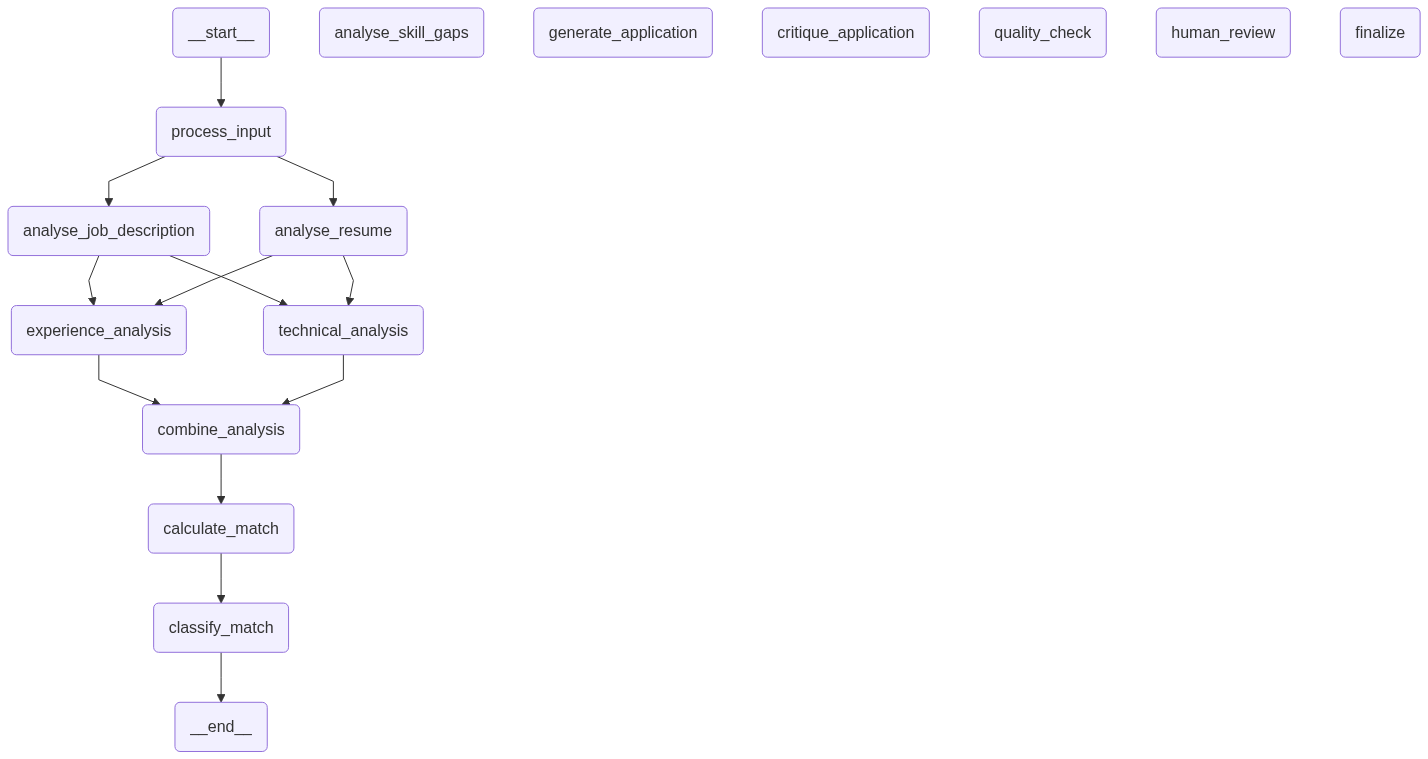

In [43]:
## workflow visualization
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))